In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology
from skimage.morphology import skeletonize
import os
import warnings
warnings.filterwarnings('ignore')

   Shape: (133, 491, 3)
   Type: uint8
   Size: 133x491 pixels


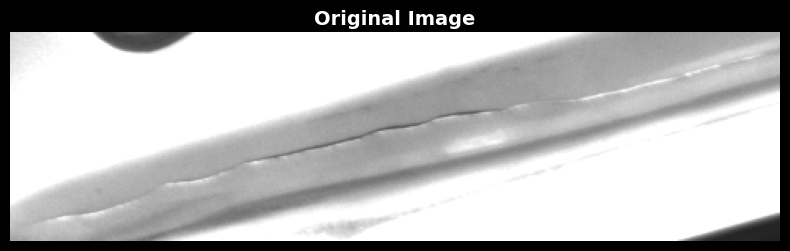

In [51]:
INPUT_PATH = 'dataset/backup/train/defect'
OUTPUT_PATH = 'dataset/backup/pre-processed/train/defect'
os.makedirs(OUTPUT_PATH, exist_ok=True)

# image_path = "/home/abdenour/PycharmProjects/crack_detect/dataset/backup/train/defect/001.png"
image_path = "/home/abdenour/PycharmProjects/crack_detect/dataset/backup/val/defect/145.png"
# Load image
original = cv2.imread(image_path)
print(f"   Shape: {original.shape}")
print(f"   Type: {original.dtype}")
print(f"   Size: {original.shape[0]}x{original.shape[1]} pixels")

# Visualize Image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

   Shape: (133, 491)
   Range: [32, 255]
   Mean: 215.36


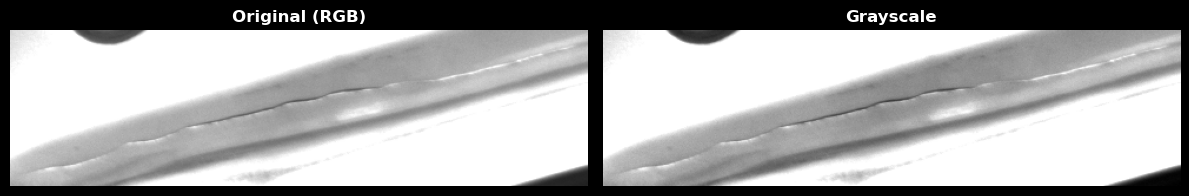

In [52]:
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
print(f"   Shape: {gray.shape}")
print(f"   Range: [{gray.min()}, {gray.max()}]")
print(f"   Mean: {gray.mean():.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (RGB)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

   Kernel size: (5, 5)
   Sigma: 1.0
   Output shape: (133, 491)


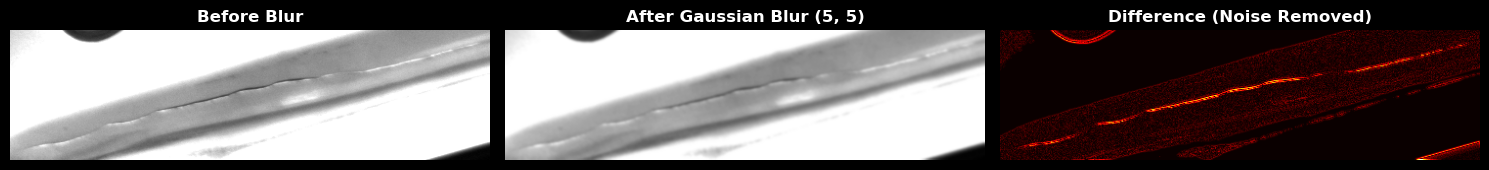

Rata-rata perbedaan = 1.41


In [53]:
gaussian_kernel = (5, 5)
sigma = 1.0

# Apply Gaussian Blur
preprocessed = cv2.GaussianBlur(gray, gaussian_kernel, sigma)
print(f"   Kernel size: {gaussian_kernel}")
print(f"   Sigma: {sigma}")
print(f"   Output shape: {preprocessed.shape}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Before Blur', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(preprocessed, cmap='gray')
axes[1].set_title(f'After Gaussian Blur {gaussian_kernel}', fontweight='bold')
axes[1].axis('off')

# Difference
diff = cv2.absdiff(gray, preprocessed)
axes[2].imshow(diff, cmap='hot')
axes[2].set_title('Difference (Noise Removed)', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Rata-rata perbedaan = {diff.mean():.2f}")

   Kernel type: disk
   Kernel size: 15x15
   Bottom-hat range: [0, 170]


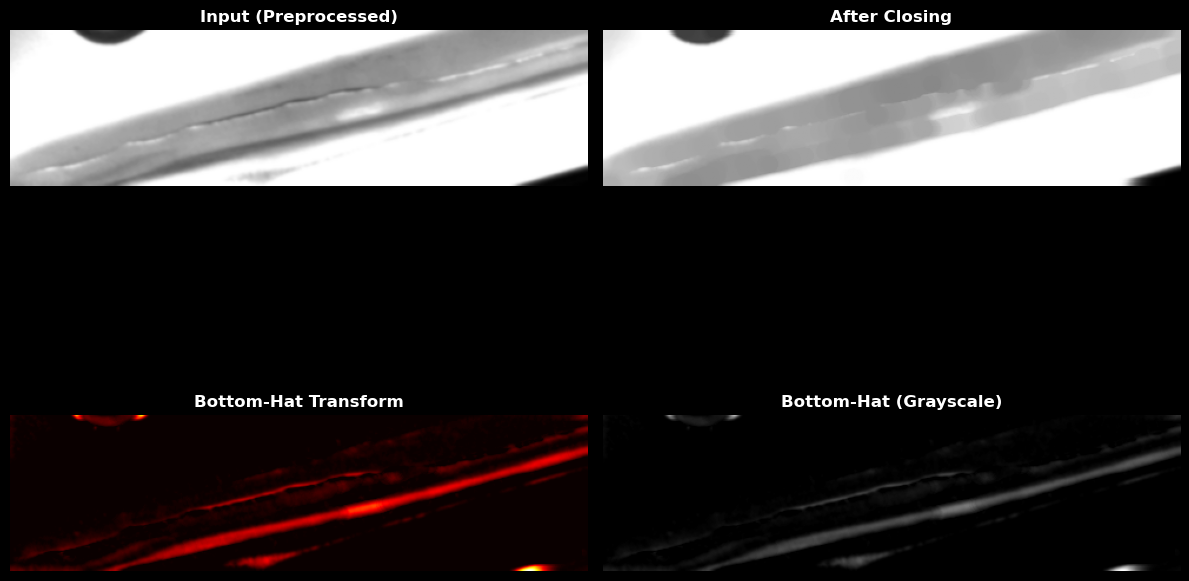

Non-zero pixels = 22609


In [54]:
# Parameter morphological filtering
kernel_size = 15
kernel_type = 'disk'

# Buat structuring element
if kernel_type == 'disk':
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
elif kernel_type == 'rect':
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

# Morphological Closing
closed = cv2.morphologyEx(preprocessed, cv2.MORPH_CLOSE, kernel)

# Bottom-Hat Transform = Closing - Original
# Ini menonjolkan fitur GELAP (retak) pada latar terang
bottom_hat = cv2.subtract(closed, preprocessed)
print(f"   Kernel type: {kernel_type}")
print(f"   Kernel size: {kernel_size}x{kernel_size}")
print(f"   Bottom-hat range: [{bottom_hat.min()}, {bottom_hat.max()}]")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(preprocessed, cmap='gray')
axes[0, 0].set_title('Input (Preprocessed)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(closed, cmap='gray')
axes[0, 1].set_title('After Closing', fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(bottom_hat, cmap='hot')
axes[1, 0].set_title('Bottom-Hat Transform', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(bottom_hat, cmap='gray')
axes[1, 1].set_title('Bottom-Hat (Grayscale)', fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Non-zero pixels = {np.count_nonzero(bottom_hat)}")

   Threshold value: 30
   Binary pixels (white): 3185
   Percentage: 4.88%


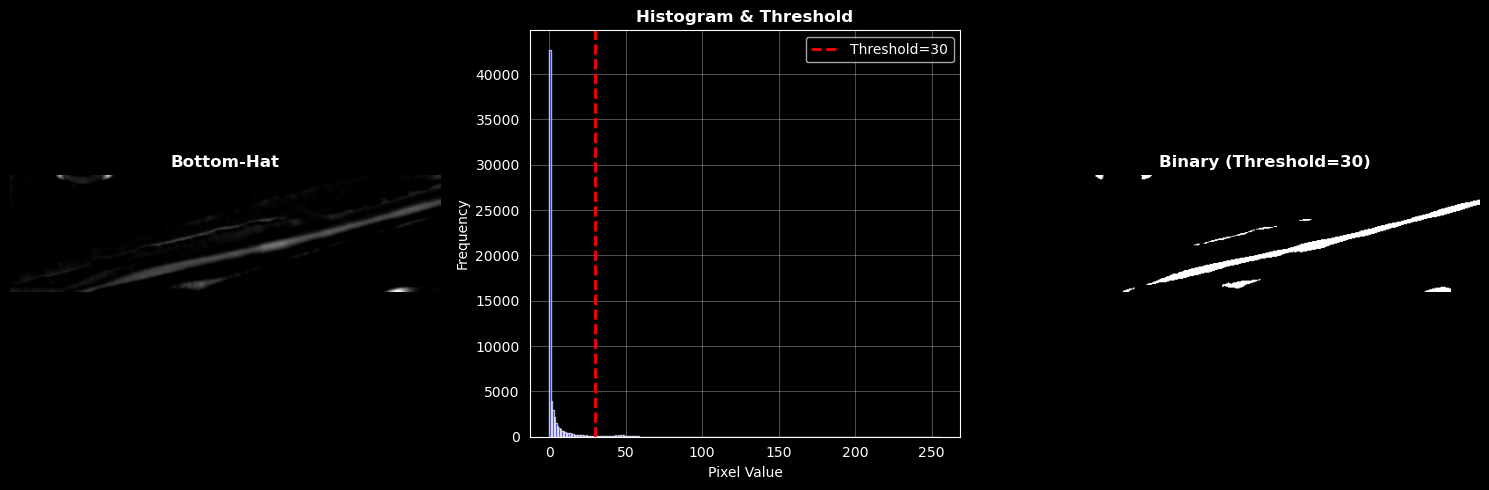

In [55]:
# Parameter thresholding
threshold_value = 30

# Apply thresholding
_, binary = cv2.threshold(bottom_hat, threshold_value, 255, cv2.THRESH_BINARY)

print(f"   Threshold value: {threshold_value}")
print(f"   Binary pixels (white): {np.count_nonzero(binary)}")
print(f"   Percentage: {(np.count_nonzero(binary)/binary.size)*100:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(bottom_hat, cmap='gray')
axes[0].set_title('Bottom-Hat', fontweight='bold')
axes[0].axis('off')

axes[1].hist(bottom_hat.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
axes[1].axvline(threshold_value, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold_value}')
axes[1].set_title('Histogram & Threshold', fontweight='bold')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].imshow(binary, cmap='gray')
axes[2].set_title(f'Binary (Threshold={threshold_value})', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

   Opening kernel: 3x3
   Closing kernel: 3x3
   Pixels before cleaning: 3185
   Pixels after cleaning: 3005
   Noise removed: 180 pixels


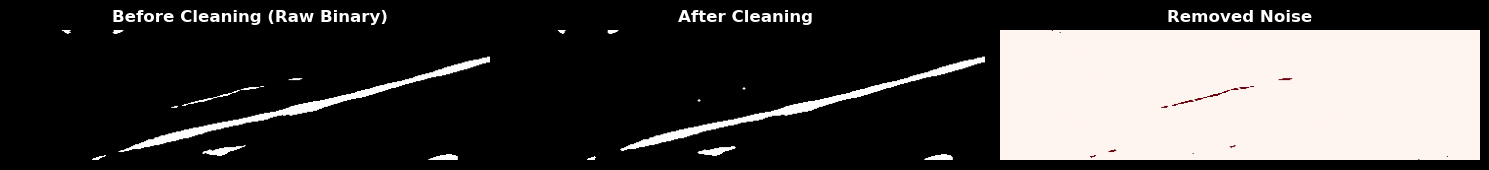

Noise kecil berhasil dihilangkan & Retak utama tetap dipertahankan


In [56]:
# Parameter cleaning
cleaning_kernel_size = 3

# Opening untuk remove noise kecil
cleaning_kernel = cv2.getStructuringElement(
cv2.MORPH_ELLIPSE,
    (cleaning_kernel_size, cleaning_kernel_size)
)
cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, cleaning_kernel)

# Closing untuk connect broken cracks
closing_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
crack_mask = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, closing_kernel)

print(f"   Opening kernel: {cleaning_kernel_size}x{cleaning_kernel_size}")
print(f"   Closing kernel: 3x3")
print(f"   Pixels before cleaning: {np.count_nonzero(binary)}")
print(f"   Pixels after cleaning: {np.count_nonzero(crack_mask)}")
print(f"   Noise removed: {np.count_nonzero(binary) - np.count_nonzero(crack_mask)} pixels")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Before Cleaning (Raw Binary)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(crack_mask, cmap='gray')
axes[1].set_title('After Cleaning', fontweight='bold')
axes[1].axis('off')

# Show removed noise
noise = cv2.subtract(binary, crack_mask)
axes[2].imshow(noise, cmap='Reds')
axes[2].set_title('Removed Noise', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Noise kecil berhasil dihilangkan & Retak utama tetap dipertahankan")

   Skeleton pixels: 461
   Original crack pixels: 3005
   Reduction: 84.7%


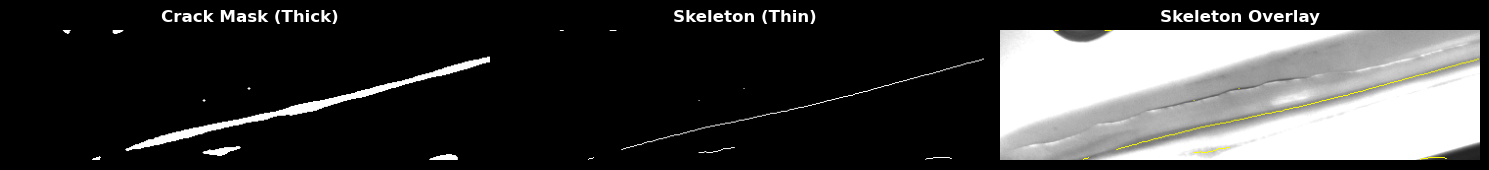

Skeletonization menghasilkan centerline retak


In [57]:
# Konversi ke binary (0 dan 1)
binary_mask = (crack_mask / 255).astype(bool)

# Skeletonize untuk mendapat centerline
skeleton = skeletonize(binary_mask).astype(np.uint8) * 255

print(f"   Skeleton pixels: {np.count_nonzero(skeleton)}")
print(f"   Original crack pixels: {np.count_nonzero(crack_mask)}")
print(f"   Reduction: {(1 - np.count_nonzero(skeleton)/np.count_nonzero(crack_mask))*100:.1f}%")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(crack_mask, cmap='gray')
axes[0].set_title('Crack Mask (Thick)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(skeleton, cmap='gray')
axes[1].set_title('Skeleton (Thin)', fontweight='bold')
axes[1].axis('off')

# Overlay skeleton on original
skeleton_overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
skeleton_overlay[skeleton > 0] = [0, 255, 255]  # Cyan
axes[2].imshow(cv2.cvtColor(skeleton_overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title('Skeleton Overlay', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Skeletonization menghasilkan centerline retak")


📊 HASIL ANALISIS RETAK
   Jumlah segmen retak: 3
   Total piksel retak: 3005
   Persentase area retak: 4.602%
   Panjang retak (approx): 461 pixels
   Area terbesar: 2208 px²
   Area terkecil: 95 px²


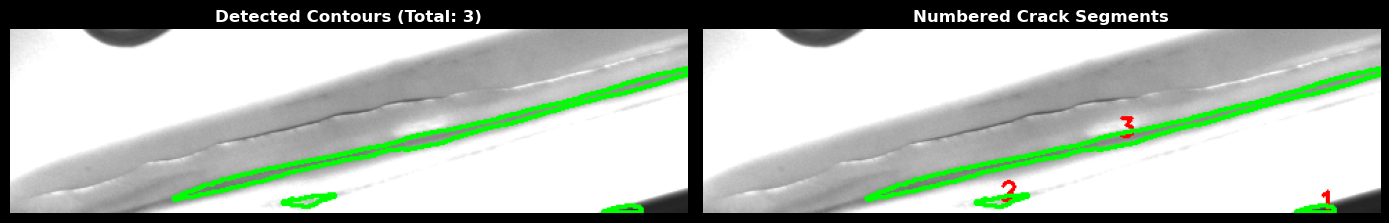

Semua segmen retak berhasil terdeteksi


In [58]:
# Deteksi kontur
contours, _ = cv2.findContours(crack_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter kontur kecil (noise yang masih tersisa)
min_area = 50
significant_contours = [c for c in contours if cv2.contourArea(c) > min_area]

# Hitung statistik
crack_pixels = np.count_nonzero(crack_mask)
total_pixels = crack_mask.shape[0] * crack_mask.shape[1]
crack_percentage = (crack_pixels / total_pixels) * 100

# Hitung total panjang retak (dari skeleton)
skeleton_pixels = np.count_nonzero(skeleton)

print(f"\n{'='*50}")
print("📊 HASIL ANALISIS RETAK")
print(f"{'='*50}")
print(f"   Jumlah segmen retak: {len(significant_contours)}")
print(f"   Total piksel retak: {crack_pixels}")
print(f"   Persentase area retak: {crack_percentage:.3f}%")
print(f"   Panjang retak (approx): {skeleton_pixels} pixels")
print(f"   Area terbesar: {max([cv2.contourArea(c) for c in significant_contours]):.0f} px²")
print(f"   Area terkecil: {min([cv2.contourArea(c) for c in significant_contours]):.0f} px²")

# Draw contours
contour_img = original.copy()
cv2.drawContours(contour_img, significant_contours, -1, (0, 255, 0), 2)

# Numbering contours
numbered_img = original.copy()
for i, contour in enumerate(significant_contours, 1):
    M = cv2.moments(contour)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(numbered_img, str(i), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
cv2.drawContours(numbered_img, significant_contours, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Detected Contours (Total: {len(significant_contours)})', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(numbered_img, cv2.COLOR_BGR2RGB))
axes[1].set_title('Numbered Crack Segments', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Semua segmen retak berhasil terdeteksi")

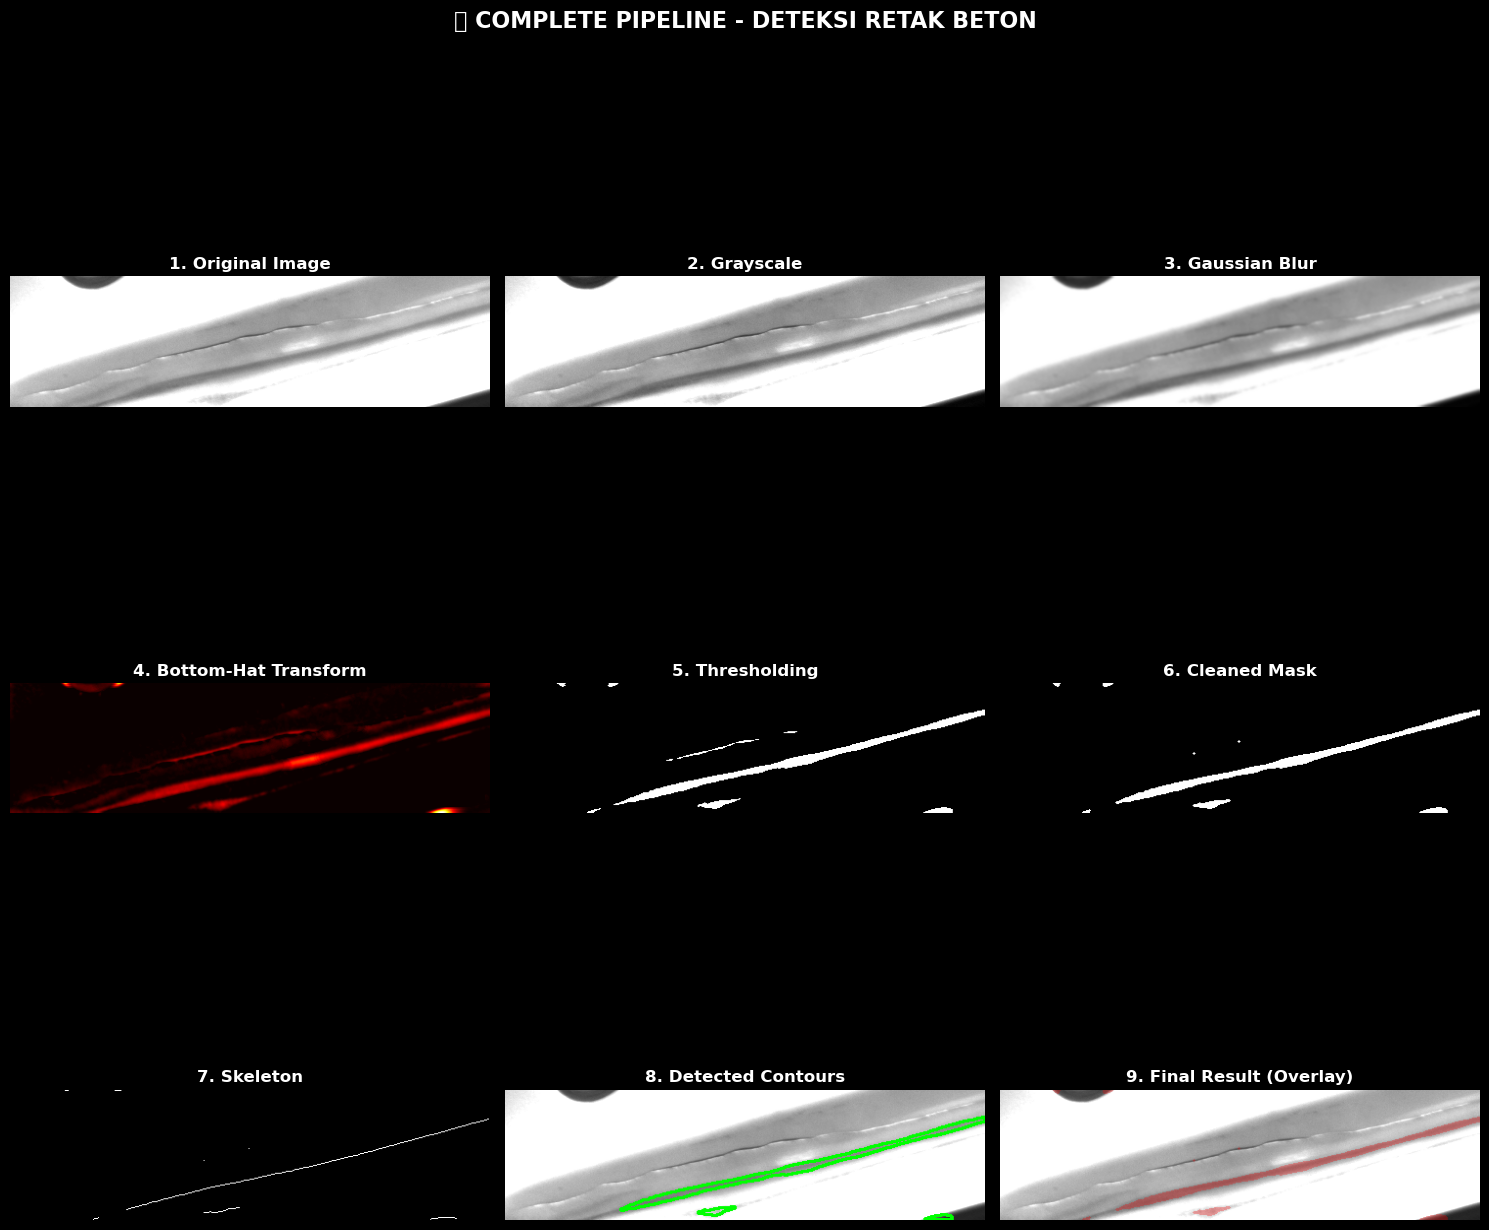

In [59]:
# Buat overlay merah untuk retak
overlay = original.copy()
overlay[crack_mask > 0] = [0, 0, 255]  # Merah (BGR)

# Blend dengan original
result = cv2.addWeighted(original, 0.7, overlay, 0.3, 0)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('🏗️ COMPLETE PIPELINE - DETEKSI RETAK BETON', fontsize=16, fontweight='bold')

# Row 1
axes[0, 0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('1. Original Image', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title('2. Grayscale', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(preprocessed, cmap='gray')
axes[0, 2].set_title('3. Gaussian Blur', fontweight='bold')
axes[0, 2].axis('off')

# Row 2
axes[1, 0].imshow(bottom_hat, cmap='hot')
axes[1, 0].set_title('4. Bottom-Hat Transform', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(binary, cmap='gray')
axes[1, 1].set_title('5. Thresholding', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(crack_mask, cmap='gray')
axes[1, 2].set_title('6. Cleaned Mask', fontweight='bold')
axes[1, 2].axis('off')

# Row 3
axes[2, 0].imshow(skeleton, cmap='gray')
axes[2, 0].set_title('7. Skeleton', fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
axes[2, 1].set_title('8. Detected Contours', fontweight='bold')
axes[2, 1].axis('off')

axes[2, 2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[2, 2].set_title('9. Final Result (Overlay)', fontweight='bold')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()